## Project Assignment - Supply Chain Analytics II

- Ammar Haider - 7447213
- Shalom Cornells - 7443777
- Dahyun Jung - 7443700

## Question 1 

#### a) Analyse the data given and provide clusters: Are there differences/ similarities between some days of the week? Evaluate which days could be weekdays and which days could be weekend days. At which times of the days does the data look similarly distributed? At which times does it differ? We recommend to analyse the data using visualisations.



In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display 

df = pd.read_csv("Project_Data.csv", sep=";")
weeks = [c for c in df.columns if c.startswith("Week")]

df = df.reset_index(drop=True)
df["hour_of_week"] = np.arange(len(df))

df["day"]  = df["hour_of_week"] // 24 + 1
df["hour"] = df["hour_of_week"] % 24

df["demand_mean"] = df[weeks].mean(axis=1)

df.head()

,index,Week 1,Week 2,Week 3,Week 4,Week 5,Week 6,Week 7,Week 8,Week 9,Week 10,Week 11,Week 12,Week 13,Week 14,hour_of_week,day,hour,demand_mean
0,1,1,2,0,1,0,0,2,1,1,2,1,0,0,1,0,1,0,0.857143
1,2,1,1,0,1,0,0,2,1,2,2,1,0,0,1,1,1,1,0.857143
2,3,1,1,0,1,0,0,2,1,2,2,1,0,0,1,2,1,2,0.857143
3,4,1,1,0,1,0,0,2,1,0,2,1,0,0,1,3,1,3,0.714286
4,5,1,2,0,1,0,0,2,1,1,2,1,0,0,1,4,1,4,0.857143


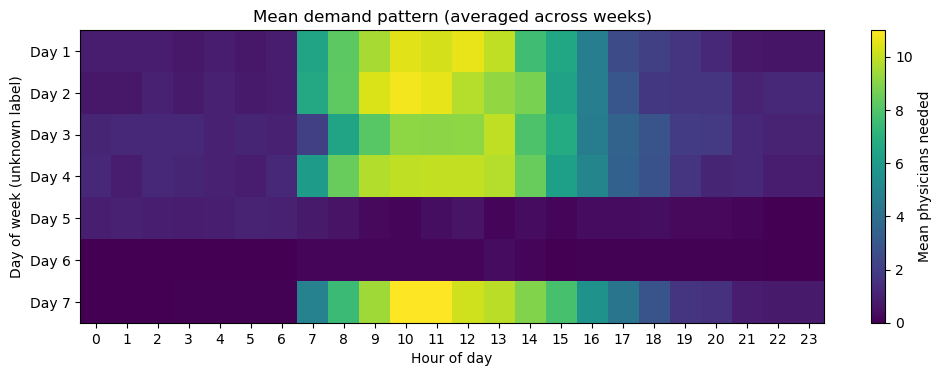

In [41]:
pivot = df.pivot_table(index="day", columns="hour", values="demand_mean")

plt.figure(figsize=(12, 3.8))
plt.imshow(pivot.values, aspect="auto")
plt.colorbar(label="Mean physicians needed")
plt.xticks(range(24), range(24))
plt.yticks(range(7), [f"Day {d}" for d in pivot.index])
plt.xlabel("Hour of day")
plt.ylabel("Day of week (unknown label)")
plt.title("Mean demand pattern (averaged across weeks)")
plt.show()


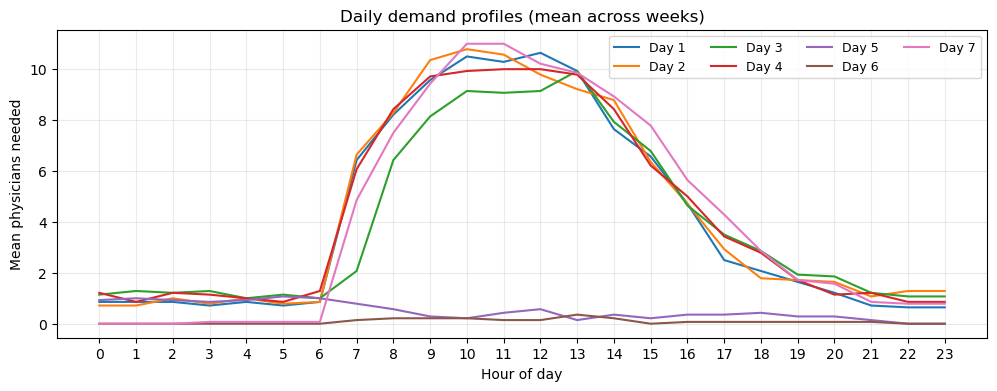

In [42]:
plt.figure(figsize=(12, 4))
for d in pivot.index:
    plt.plot(pivot.columns, pivot.loc[d].values, label=f"Day {d}")

plt.xticks(range(24))
plt.xlabel("Hour of day")
plt.ylabel("Mean physicians needed")
plt.title("Daily demand profiles (mean across weeks)")
plt.legend(ncol=4, fontsize=9)
plt.grid(True, alpha=0.25)
plt.show()


In [43]:
from sklearn.cluster import KMeans

# K-means clustering to group days by their demand patterns.
X = pivot.values  # shape (7 days, 24 hours)
km = KMeans(n_clusters=2, random_state=0, n_init=20).fit(X)

day_cluster = pd.Series(km.labels_, index=pivot.index, name="cluster")
daily_total = pivot.sum(axis=1).rename("daily_total_mean")

summary_days = pd.concat([daily_total, day_cluster], axis=1).sort_values("daily_total_mean")
summary_days


,daily_total_mean,cluster
day,,
6,2.071429,1
5,12.142857,1
3,94.857143,0
7,99.357143,0
1,99.642857,0
2,103.071429,0
4,103.142857,0


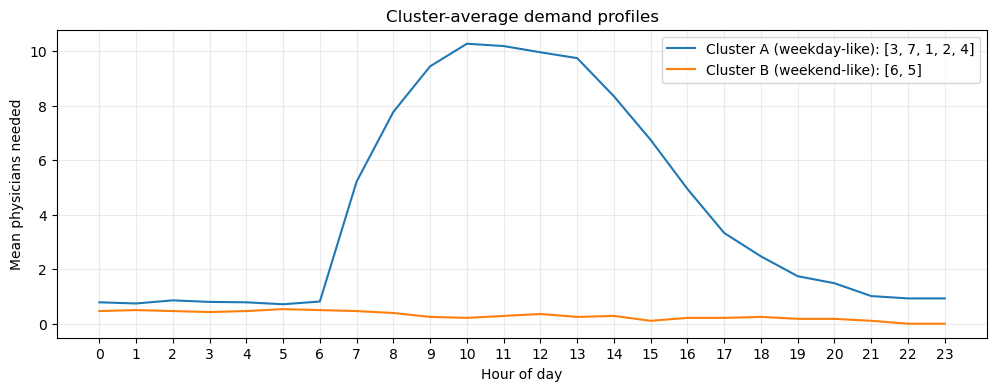

([3, 7, 1, 2, 4], [6, 5])

In [44]:
weekday_like = summary_days[summary_days["cluster"] == summary_days["cluster"].mode()[0]].index.tolist()
weekend_like = summary_days[summary_days["cluster"] != summary_days["cluster"].mode()[0]].index.tolist()

weekday_profile = pivot.loc[weekday_like].mean(axis=0)
weekend_profile = pivot.loc[weekend_like].mean(axis=0)

plt.figure(figsize=(12, 4))
plt.plot(pivot.columns, weekday_profile.values, label=f"Cluster A (weekday-like): {weekday_like}")
plt.plot(pivot.columns, weekend_profile.values, label=f"Cluster B (weekend-like): {weekend_like}")
plt.xticks(range(24))
plt.xlabel("Hour of day")
plt.ylabel("Mean physicians needed")
plt.title("Cluster-average demand profiles")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

weekday_like, weekend_like


### Interpretation

Visual analysis using heatmap, line graphs, and K-Means clustering show structural differences. 
- The heatmap of mean demand shows differences across days. Day 1-4 and 7 exhibit strong daytime demand peaks, whereas Days 5 and 6 show consistently low demand throughout the entire day. This contrast is also visible in the daily demand line graphs, where Days 1-4 and 7 follow similar high-demand curves, while Day 5 and 6 remain flat and near minimal staffing levels.  
- K-Means clustering of 24 hour demand confirms this finding. Two clusters are found. One cluster contains Days 1,2,3,4 and 7, which exhibit high daytime demand. Cluster-average demand graph shows the similar behaviour. The second cluster contains Days 5 and 6, which show consistently low demand throughout the entire day as well as minimal movement on the graph near low staffing level.

Based on typical hospital operations, the high-demand cluster can be interpreted as WEEKDAY-LIKE and the low-demand cluster as WEEKEND-LIKE days.

In terms of similarities, across the day, demand follows a consistent and similar structure followed by multiple visualisations. During weekdays:
- Early shift (8:00-16:00): the highest demand possibly due to surgeries and daytime hospital activity.
- Late shift (16:00-24:00): moderate demand as operations taper off.
- Night shift (00:00-8:00): the lowest and most uniform demand possibly due to emergency and inpatinet care.

Differences are most pronounced during daytime hours, particularly within the Early shift, where staffing needs increase sharply for high-demand days but remain minimal for low-demand days. Late shift demand also differs but to a lesser extent.

#### b) Give the mean, median, standard deviation, maximum and minimum for each shift type in your cluster.

In [45]:
def shift_from_hour(h):
    if 8 <= h <= 15:
        return "Early (08-16)"
    elif 16 <= h <= 23:
        return "Late (16-24)"
    else:
        return "Night (00-08)"

# Long format across all weeks (treat each week as an observation scenario)
df_long = df.melt(id_vars=["day", "hour"], value_vars=weeks, var_name="week", value_name="demand")
df_long["shift"] = df_long["hour"].apply(shift_from_hour)

df_long["cluster"] = np.where(df_long["day"].isin(weekend_like), "Weekend-like", "Weekday-like")

stats = (df_long
         .groupby(["cluster", "shift"])["demand"]
         .agg(["mean", "median", "std", "min", "max"])
         .round(3)
        )

stats


mean  median    std  min  max
cluster      shift                                        
Weekday-like Early (08-16)  9.057     9.0  2.306    0   15
             Late (16-24)   2.105     2.0  1.932    0    9
             Night (00-08)  1.339     1.0  2.115    0   11
Weekend-like Early (08-16)  0.268     0.0  0.527    0    3
             Late (16-24)   0.143     0.0  0.399    0    2
             Night (00-08)  0.478     0.0  1.002    0    4

### Interpretation

The statistics provide a quantitative comparison of demand patterns between weekday-like and weekend-like clusters. In the weekday-like cluster, the Early shift (08–16) has by far the highest central tendency (mean = 9.06, median=9), which indicates that peak hospital activity is concentrated during daytime hours. This reflects scheduled surgeries and other procedures and services that are typical of working hours at hospital operations. The Late shift (16–24) and Night shift (00–08) are much lower on average, though higher maximum values and variability indicate irregular peak demand, which remains relevant for minimum coverage planning.

In contrast, the weekend-like cluster show that all shifts have low mean and median values close to zero. This suggests that most scheduled surgiers/procedures are reduced or even absent on these days on average. Consequently, we can suspect that the staffing requirements during weekends are driven by emergency care or monitoring of existing patients, hence the low variability across weekend-like cluster shows reduced demand trend as well. 

## Modelling choices and assumptions for Q2 and Q4

1. Emergency coverage interpretation `max(demand,1)`

The project outline states that there has to be one physician on duty in case of emergencies, but **it does not specify whether this physician should be modelled as an addition to the demand or simply ensure minimum presence**. We interpret it as a floor and therefore model hourly staffing requirements as `max(demand,1)`. This ensures that one physician is always scheduled when estimated demand is zero, while no additional physician is added when demand is already positive, allowing scheduled physicians to handle emergency cases among themselves. This interpretation aligns with the objective of minimising the number of physicians and avoiding unnecessary slack capacity. Using an alternative such as `demand+1` would impose an additional buffer in every hour and significantly increase both staffing requirements and cost.

2. Shift-day convention for the night shift.

The night shift runs from 00:00-08:00 of the following calendar day (d+1), while the early and late shifts occur within calender day d. **This creates an ambiguity in whether the night shift should be labeled as part of day `d+1` (belonging to the day it occurs or calender interpretation) or as part of the preceding day's duty cycle of day `d` (schedule interpretation)**. We assign night shift of calendar day `d+1` to the previous schedule day `d`. In other words, each schedule day `d` consists of a continuous three-shift duty block (Early(d),Late(d), and Night (d+1)). This convention ensures the structure "three 8-hour shifts per day" as stated in th eoutline and makes sure that cyclic transition constraints are applied consistently. 

For the same reason, we interpret the constraint of "two consecutive days off" as two consecutive schedule days off. **Since the outline does not explicitly define whether "day" refers to a calendar day or a scheduling duty day**, applying a consistent schedule-day convention across coverage, rest, and off-day constraints ensures internal coherence of the model.

## Question 2

#### The physicians work in three 8 – hour shifts per day with the first shift starting at 8.00 am and finishing at 4.00 pm (“early shift”), the second going from 4.00 pm until 12.00 pm (“late shift”) and the last going from 0.00 am to 8.00 am of the following day (“night shift”). Note that between shifts they have to take at least 10 hours off. In total, they are allowed to work 40 hours a week and should have two consecutive days off. 
#### Physicians can only work two kind of shifts per week, that is, either they work early and late shifts, or they work late and night shifts, or they work night and early shifts. Moreover, they are not allowed to work more than three consecutive night shifts. As physicians are expensive employees you do not want to have slack physicians and minimise the total number of anaesthesiologists you require. However, you always want enough physicians to be present to cover the demand that you derived from previous data at each hour and there always has to be one physician on duty in case of emergencies. 
#### Formulate the minimisation problem explaining each constraint and the objective. Solve the problem and present your schedule for one week, where we assume that the plan is cyclic, i.e. it ends on Sunday and starts again on Monday. Thus, working the late shift on Sunday and then working the early shift on Monday morning again is not possible for one physician.

In [46]:
import gurobipy as gp
from gurobipy import GRB

df = pd.read_csv("Project_Data.csv", sep=";").reset_index(drop=True)

weeks = [c for c in df.columns if c.startswith("Week")]

df["mean_demand"] = df[weeks].mean(axis=1)

# Hour mapping
df["h"] = np.arange(1, len(df) + 1)
df["day"]  = (df["h"] - 1) // 24 + 1
df["hour"] = (df["h"] - 1) % 24

# Shift mapping
DAYS   = list(range(1, 8))
SHIFTS = ["E", "L", "N"]
PATTERNS = ["EL", "LN", "NE"]

def next_day(d):
    return 1 if d == 7 else d + 1

def prev_day(d):
    return 7 if d == 1 else d - 1

def hour_to_shift(hr):
    if 8 <= hr <= 15:
        return "E"
    elif 16 <= hr <= 23:
        return "L"
    else:
        return "N"

df["shift_type"] = df["hour"].apply(hour_to_shift)

# Night shift belongs to previous day
df["shift_day"] = df["day"]
night_mask = df["shift_type"] == "N"
df.loc[night_mask, "shift_day"] = df.loc[night_mask, "shift_day"].apply(prev_day)

#Emergency rule: max(mean demand,1) 
#"One physician on duty in case of emergencies" enforces 1 when 0 mean demand
df["req"] = np.maximum(np.ceil(df["mean_demand"]), 1).astype(int)

print("Max hourly requirement:", df["req"].max())

# --- Safety Check 1: prev_day mapping ----------------
# Shift labels valid?
assert set(df["shift_type"]).issubset({"E","L","N"})
assert set(df["shift_day"]).issubset(set(DAYS))

# All hours 00–08 must be night of previous day
night_rows = df[df["hour"] < 8]

assert all(night_rows["shift_type"] == "N")
assert all(
    night_rows["shift_day"].values ==
    night_rows["day"].apply(prev_day).values
)
print("prev_day mapping check passed.")

# - Safety Check 2: emergency rule ----------------
#one physician on duty at all times -> one physician for zero demand hour, no additional physician otherwise.
assert df["req"].min() >= 1
print("Emergency floor check passed.")


Max hourly requirement: 11
prev_day mapping check passed.
Emergency floor check passed.


In [47]:
assert len(df) == 168
assert df["day"].min() == 1 and df["day"].max() == 7
assert df["hour"].min() == 0 and df["hour"].max() == 23
assert (df["req"] >= 1).all()

print("All data integrity checks passed.")

All data integrity checks passed.


In [48]:
DAYS = list(range(1, 8))  # 1..7 (cyclic week)

def next_day(d: int) -> int:
    return 1 if d == 7 else d + 1

def prev_day(d: int) -> int:
    return 7 if d == 1 else d - 1

# Shift structure:
# E: 08–16 of day d
# L: 16–24 of day d
# N: 00:00–08:00 of day d+1 → corresponds to hourly slots 0–7 of calendar day d
# → covered by NIGHT shift of prev_day(d)

SHIFTS = ["E", "L", "N"]
PATTERNS = ["EL", "LN", "NE"]

# Bounds from total required physician-hours
total_phys_hours = int(df["req"].sum())

lb_hours = int(np.ceil(total_phys_hours / 40))

# Each physician ≤ 5 shifts/week (8h each)
Nmax = int(df["req"].max()) * 7

print("Total required physician-hours:", total_phys_hours)
print("Lower bound from hours/40:", lb_hours)
print("Nmax candidate physicians:", Nmax)

PHYS = list(range(1, Nmax + 1))

Total required physician-hours: 602
Lower bound from hours/40: 16
Nmax candidate physicians: 77


In [49]:
# -------------------------Model----------------------

m = gp.Model("Q2_Scheduling")

# Candidate physician pool
Nmax = int(df["req"].max()) * 7
PHYS = list(range(1, Nmax + 1))

# Decision variables
x = m.addVars(PHYS, DAYS, SHIFTS, vtype=GRB.BINARY, name="x")
scheduled = m.addVars(PHYS, vtype=GRB.BINARY, name="scheduled")

# Pattern selection
p = m.addVars(PHYS, PATTERNS, vtype=GRB.BINARY, name="p")

# Off-days + consecutive off tracking
off = m.addVars(PHYS, DAYS, vtype=GRB.BINARY, name="off")
w   = m.addVars(PHYS, DAYS, vtype=GRB.BINARY, name="w")

# Objective
m.setObjective(
    gp.quicksum(scheduled[i] for i in PHYS),
    GRB.MINIMIZE
)

def work(i,d):
    return gp.quicksum(x[i,d,s] for s in SHIFTS)

In [50]:
# -------Constraints------------------------

# Constraint 1 — One shift per day OR off
for i in PHYS:
    for d in DAYS:
        m.addConstr(work(i,d) + off[i,d] == 1)

        for s in SHIFTS:
            m.addConstr(x[i,d,s] <= scheduled[i])

# Safety for "no slack physicians": if scheduled, must work at least one shift
for i in PHYS:
    m.addConstr(
        gp.quicksum(x[i,d,s] for d in DAYS for s in SHIFTS) >= scheduled[i],
        name=f"used_means_works[{i}]"
    )
    
# Constraint 2 — ≤ 40 hours (≤ 5 shifts)
for i in PHYS:
    m.addConstr(
        gp.quicksum(x[i,d,s] for d in DAYS for s in SHIFTS)
        <= 5 * scheduled[i]
    )

# Constraint 3 — Only two shift types
for i in PHYS:
    m.addConstr(
        gp.quicksum(p[i,k] for k in PATTERNS)
        == scheduled[i]
    )

for i in PHYS:
    for d in DAYS:
        m.addConstr(x[i,d,"E"] <= p[i,"EL"] + p[i,"NE"])
        m.addConstr(x[i,d,"L"] <= p[i,"EL"] + p[i,"LN"])
        m.addConstr(x[i,d,"N"] <= p[i,"LN"] + p[i,"NE"])

# Constraint 4 — 10-hour rest
for i in PHYS:
    for d in DAYS:
        dn = next_day(d)

        m.addConstr(x[i,d,"L"] + x[i,dn,"E"] <= 1)
        m.addConstr(x[i,d,"N"] + x[i,dn,"E"] <= 1)
        m.addConstr(x[i,d,"N"] + x[i,dn,"L"] <= 1)

# Constraint 5 — Max 3 consecutive nights
for i in PHYS:
    for start in DAYS:
        window = [((start-1+k)%7)+1 for k in range(4)]
        m.addConstr(
            gp.quicksum(x[i,d,"N"] for d in window) <= 3
        )

# Constraint 6 — Two consecutive days off
for i in PHYS:
    for d in DAYS:
        dn = next_day(d)

        m.addConstr(w[i,d] <= off[i,d])
        m.addConstr(w[i,d] <= off[i,dn])
        m.addConstr(w[i,d] >= off[i,d] + off[i,dn] - 1)

    m.addConstr(
        gp.quicksum(w[i,d] for d in DAYS)
        >= scheduled[i]
    )

# Constraint 7 — Coverage constraints
for t in range(len(df)):

    d_cov = int(df.loc[t,"shift_day"])
    s_cov = df.loc[t,"shift_type"]
    req   = int(df.loc[t,"req"])
    staff = gp.quicksum(x[i,d_cov,s_cov] for i in PHYS)
    m.addConstr(staff >= req)

In [51]:
m.setParam("OutputFlag", 1)
m.optimize()

print("Status:", m.Status)

if m.Status == GRB.OPTIMAL:
    used = [i for i in PHYS if scheduled[i].X > 0.5]
    print("Optimal physicians:", len(used))

Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 8022 rows, 3003 columns and 36652 nonzeros (Min)
Model fingerprint: 0xe2d51595
Model has 77 linear objective coefficients
Variable types: 0 continuous, 3003 integer (3003 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+01]
Found heuristic solution: objective 77.0000000
Presolve removed 2303 rows and 0 columns
Presolve time: 0.07s
Presolved: 5719 rows, 3003 columns, 23177 nonzeros
Variable types: 0 continuous, 3003 integer (3003 binary)

Root relaxation: objective 2.400000e+01, 5070 iterations, 0.66 seconds (0.16 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incu

In [52]:
# ---------- Weekly schedule + coverage verification ----

if m.SolCount == 0:
    print("No feasible solution found, cannot build schedule.")
else:
    used = [i for i in PHYS if scheduled[i].X > 0.5]

    day_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    sched = pd.DataFrame(index=[f"P{i:02d}" for i in used], columns=day_names)

    for i in used:
        for d in DAYS:
            assigned = [s for s in SHIFTS if x[i, d, s].X > 0.5]
            sched.loc[f"P{i:02d}", day_names[d-1]] = assigned[0] if assigned else "OFF"

    display(sched)

    # Verify hourly coverage
    violations = 0
    min_slack = 10**9
    worst = None

    for t in range(len(df)):
        d_cov = int(df.loc[t, "shift_day"])
        s_cov = str(df.loc[t, "shift_type"])
        req   = int(df.loc[t, "req"])

        staff = int(round(sum(x[i, d_cov, s_cov].X for i in used)))
        slack = staff - req

        if slack < 0:
            violations += 1
        if slack < min_slack:
            min_slack = slack
            worst = (t+1, int(df.loc[t,"day"]), int(df.loc[t,"hour"]), d_cov, s_cov, staff, req)

    print("Coverage violations:", violations)
    print("Minimum slack (should be >= 0):", min_slack)
    print("Worst hour-slot (h, cal_day, hour, cov_day, shift, staff, req):", worst)

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
P01,N,OFF,N,OFF,OFF,N,N
P02,N,N,OFF,OFF,E,E,N
P03,N,N,OFF,OFF,L,OFF,N
P04,N,OFF,N,OFF,OFF,N,N
P05,OFF,OFF,E,E,N,N,N
P06,N,OFF,N,OFF,OFF,N,N
P07,N,OFF,N,OFF,OFF,N,N
P08,E,E,N,N,OFF,OFF,E
P09,E,E,E,E,OFF,OFF,E
P10,E,E,E,E,OFF,OFF,E


Coverage violations: 0
Minimum slack (should be >= 0): 0
Worst hour-slot (h, cal_day, hour, cov_day, shift, staff, req): (8, 1, 7, 7, 'N', 7, 7)


Min slack (should be ≥ 0): 0


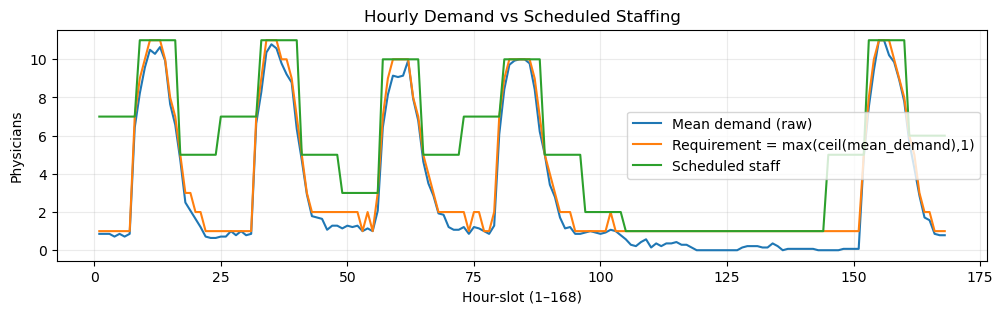

In [53]:
import matplotlib.pyplot as plt

if m.SolCount == 0:
    print("No feasible solution available to plot.")
else:
    used = [i for i in PHYS if scheduled[i].X > 0.5]

    staff_ds = {(d, s): int(round(sum(x[i, d, s].X for i in used)))
                for d in DAYS for s in SHIFTS}

    staff_hour = []
    for t in range(len(df)):
        d_cov = int(df.loc[t, "shift_day"])
        s_cov = str(df.loc[t, "shift_type"])
        staff_hour.append(staff_ds[(d_cov, s_cov)])

    check = df[["h", "day", "hour", "mean_demand", "req"]].copy()
    check["staff"] = staff_hour
    check["slack"] = check["staff"] - check["req"]

    print("Min slack (should be ≥ 0):", check["slack"].min())

    plt.figure(figsize=(12, 3))
    plt.plot(check["h"], check["mean_demand"], label="Mean demand (raw)")
    plt.plot(check["h"], check["req"], label="Requirement = max(ceil(mean_demand),1)")
    plt.plot(check["h"], check["staff"], label="Scheduled staff")
    plt.xlabel("Hour-slot (1–168)")
    plt.ylabel("Physicians")
    plt.title("Hourly Demand vs Scheduled Staffing")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

### Interpretation

Under the modelling assumptions defined earlier - particularly the emergency floor rule and the schedule-day shift convention - the optimisation determines the minimum number of physicians required to cover weekly demand while satisfying all constraints. The optimized solution shows that **24 physicians** are sufficient to meet all hourly requirements. Coverage verification confirms feasibility with zero coverage violations and a minimum slack value of zero, meaning staffing never falls below required demand. 

The demand-staffing plot above supports this result visually, showing that scheduled staffing (green) consistently meets or exceeds required demand (orange) curve. The requirement line closely follows mean demand but is floored at one physician due to the emergency assumption. Also, the stepwise scheduled staffing pattern reflects the fixed 8-hour shift design, meaning staffing cannot adjust hour-by-hour to demand fluctuations. As a result, mild overcoverage appears during low-demand period. 

Peak daytime demand is matched more tightly, indicating that the schedule is primarily driven by Early shift requirements. The weekly schedule further confirms this pattern, with a higher concentration of physicians assigned to Early shifts, in Late shifts and lean but sufficient coverage in Night shifts. Even the result of _worst-hour slot_ achieves exact coverage, demonstrating robustness of the solution. Overall, the model achieves cost-efficient staffing plan that maintains required level of service while respecting operational constraints. 

## Question 3

#### Analyse how well your solution performs by simulating over the given weeks. Please discuss the following two measures:

#### a) What is the total undercoverage of demand measured in physician-hours per shift?
#### Example: One physician-hour undercoverage means that for one hour in the shift, you required one physician more than you scheduled. Two physician-hours undercoverage could mean that for two hours you required one physician more than you scheduled or that for one hour you required two physicians more than you scheduled.

In [54]:
assert m.SolCount > 0  # checking if Q2 has a feasible solution

# Use only scheduled physicians
used = [i for i in PHYS if scheduled[i].X > 0.5]

def prev_day(d): return 7 if d == 1 else d - 1
def cover_shift_for_hour(day, hour):
    if 8 <= hour <= 15: return day, "E"
    if 16 <= hour <= 23: return day, "L"
    return prev_day(day), "N"   # 00–07 belongs to previous day's night shift

# staff per (day,shift) from Q2 schedule
staff_ds = {(d, s): int(round(sum(x[i, d, s].X for i in used)))
            for d in range(1, 8) for s in ["E", "L", "N"]}

# staff per hour-slot (based on which day-shift covers the hour)
shift_type = np.empty(len(df), dtype=object)
staff_hour = np.zeros(len(df), dtype=int)

for k, r in enumerate(df.itertuples(index=False)):
    d = int(r.day); hr = int(r.hour)
    sd, st = cover_shift_for_hour(d, hr)
    shift_type[k] = st
    staff_hour[k] = staff_ds[(sd, st)]

rows = []
for w in weeks:
    req = np.maximum(np.ceil(df[w].values), 1).astype(int)
    under = np.maximum(0, req - staff_hour)
    rows.append({
        "week": w,
        "E": int(under[shift_type == "E"].sum()),
        "L": int(under[shift_type == "L"].sum()),
        "N": int(under[shift_type == "N"].sum()),
    })

under_by_week_shift = pd.DataFrame(rows).set_index("week")
display(under_by_week_shift)

total_under_by_shift = under_by_week_shift.sum(axis=0).to_frame("Total undercoverage (physician-hours)")
display(total_under_by_shift)

,E,L,N
week,,,
Week 1,18,8,0
Week 2,13,5,6
Week 3,7,3,3
Week 4,5,3,2
Week 5,19,2,4
Week 6,9,5,3
Week 7,6,1,4
Week 8,22,9,12
Week 9,14,4,5


,Total undercoverage (physician-hours)
E,162
L,57
N,82


### Interpretation

While the Q2 model guarantees full coverage under mean demand assumptions, real weekly demand fluctuates, causing undercoverage. The results show that shortages occurs in all shift type, but its magnitude differs. The Early shift experiences the highest total undercoverage (162 physician-hours), indicating the concentration of peak daytime demand and inability to match workloads with fixed staffing levels. 

The Night shift records the second-highest (82 physician-hours), indicating that even though average demand is lower at night, variability can still create coverage gaps. In contrast, the Late shift shows the lowest undercoverage (57 physician-hours), suggesting that its moderate demand levels are more consistently satisfied by the Q2 staffing plan. Also, weekly patterns reveal that sepcific high-demand weeks (weeks 8,10,11) drive much of the total shortage, highlighting the effect of demand variability.

These findings highlight the limitation of planning solely on mean demand, as average values fail to capture peak variability of demand. Although the emergency floor assumption `max(demand,1)` ensures minimum coverage in zero-demand hours, it does not provide additional buffer capacity for extreme demand spikes. Overall, the deterministic schedule remains feasible and relatively robust, but demonstrates vulnerability to demand uncertainty. 

#### b) What is the average utilization of physicians per shift?
#### Example: If you have 4 physicians scheduled, and demand is 3 physicians, your utilization for this hour is 75%.

In [55]:
util_by_week_shift = pd.DataFrame(index=weeks, 
                                  columns=["E", "L", "N", "Total"], dtype=float)

for w in weeks:
    req = np.maximum(np.ceil(df[w].values), 1).astype(int)

    # hourly utilization = min(req, staff) / staff  (caps at 1)
    util_h = np.zeros(len(df), dtype=float)
    np.divide(np.minimum(req, staff_hour), staff_hour, out=util_h, where=(staff_hour > 0))

    util_by_week_shift.loc[w, "E"] = util_h[shift_type == "E"].mean()
    util_by_week_shift.loc[w, "L"] = util_h[shift_type == "L"].mean()
    util_by_week_shift.loc[w, "N"] = util_h[shift_type == "N"].mean()
    util_by_week_shift.loc[w, "Total"] = util_h.mean()

display(util_by_week_shift.style.format("{:.3f}"))

print("Average utilization across ALL weeks:")
display(util_by_week_shift.mean().to_frame("avg_utilization").style.format("{:.3f}"))

,E,L,N,Total
Week 1,0.927,0.652,0.477,0.685
Week 2,0.891,0.617,0.514,0.674
Week 3,0.881,0.543,0.418,0.614
Week 4,0.813,0.550,0.403,0.589
Week 5,0.921,0.635,0.427,0.661
Week 6,0.902,0.544,0.421,0.622
Week 7,0.852,0.557,0.475,0.628
Week 8,0.915,0.702,0.525,0.714
Week 9,0.864,0.611,0.475,0.650
Week 10,0.879,0.651,0.507,0.679


Average utilization across ALL weeks:


,avg_utilization
E,0.878
L,0.596
N,0.456
Total,0.643


### Interpretation

Average physician utilisation is about 64.3%, indicating that a notable share of scheduled capacity is unused when the deterministic schedule from Q2 is evaluated under real weekly demand. Utilisation is highest in the Early shift at 87.8%, reflecting that the staffing aligns well with peak hospital activity during daytime hours where demand is most concentrated. The Late shift shows moderate utilisation of about 59.6%, suggesting that while demand is lower than daytime levels, a reasonable portion of scheduled physicians is still required. 

The Night shift shows the lowest utilisation (45.6%), consistent with its lower and more stable demand pattern we analysed previously. This distribution highlights how demand intensity varies across shifts while staffing remains fixed due to the deterministic planning in Q2. Because physicians are scheduled in full shifts, staffing cannot adjust to these hourly fluctuations of demand. 

As a result, lower-demand periods generate idle capacity, particularly night hours, while peak daytime hours operate much closer to full utilisation. Overall, the utilisation outcomes suggest that the deterministic staffing plan maintains reliable service coverage but with moderate efficiency when tested against stochastic demand.

#### c) How can your results be explained by the assumptions you took in Question 2? Would you change some of your assumptions based on your results of Parts a and b?

The results from Q3(a) and (b) can be explained by the assumptions made in Q2. In Q2, staffing was optimised based on mean demand rather than stochastic demand, making a schedule that fits an average week well but does not fully fit peak-demand weeks. This explains the undercoverage observed in several weeks (weeks 8,10,11), particularly during Early shifts where demand variability was highest. 

Utilisation results reflect the fixed 8-hour shift assumed in Q2. Because physicians are forced to stay scheduled, they remain on duty even when hourly demand falls, creating idle capacity, especially in Late and Night shifts. This rigidity reduces the model's responsiveness to real demand fluctuations.

Labour constraints such as rest times, working hours and limits on consecutive night shifts also limit staffing flexiblity, making it harder to align schedules with realised demand. The emergency coverage assumption of `max(demand,1)` also maintains baseline staffing levels even in very low-demand hours, contributing to slightly to underutilised capacity. 

Based on these findings, both the **8-hour shift and mean-demand assumptions** could be reconsidered. Incorporating stochastic demand would allow staffing levels to better refelct peak variability and reduce undercoverage. Additionally, introducing more flexible shift structure could improve utilisation and responsiveness to hourly demand changes. For example, allowing shorter shift legnths or flexible start times could better align staffing with real demand patterns and reduce idle capacity during low demand periods.

## Question 4

#### Now perform a stochastic optimisation and minimise the number of physicians over the given scenarios such that the expected undercoverage, i.e. you need more physicians than you actually have, is not more than 1 physician-hours per shift. Produce one schedule. How many physicians do you need? Do you have to employ more physicians than before? Which constraint/ assumption in your model of Question 2 led to the higher/ lower number of physicians?

In [56]:
#-------As new optimisation model, we start from loading data------
# Load scenarios
df = pd.read_csv("Project_Data.csv", sep=";").reset_index(drop=True)
weeks = [c for c in df.columns if c.startswith("Week")]
W = len(weeks)

# Hour mapping: 168 rows = 7*24
df["h"] = np.arange(1, len(df) + 1)
df["day"]  = (df["h"] - 1) // 24 + 1      # 1..7
df["hour"] = (df["h"] - 1) % 24           # 0..23

# Sets (same as Q2)
DAYS = list(range(1, 8))
SHIFTS = ["E", "L", "N"]
PATTERNS = ["EL", "LN", "NE"]

def next_day(d): return 1 if d == 7 else d + 1
def prev_day(d): return 7 if d == 1 else d - 1

def hour_to_shift(hr):
    if 8 <= hr <= 15: return "E"
    if 16 <= hr <= 23: return "L"
    return "N"

df["shift_type"] = df["hour"].apply(hour_to_shift)

# prev_day convention: hours 00–07 of calendar day d belong to NIGHT of prev_day(d)
df["shift_day"] = df["day"]
night_mask = (df["shift_type"] == "N")
df.loc[night_mask, "shift_day"] = df.loc[night_mask, "shift_day"].apply(prev_day)

# Safety checks
assert len(df) == 168
assert df["day"].min() == 1 and df["day"].max() == 7
assert df["hour"].min() == 0 and df["hour"].max() == 23
assert set(df["shift_type"]).issubset({"E","L","N"})
assert set(df["shift_day"]).issubset(set(DAYS))

print("Scenarios:", W)

# Scenario requirements matrix req[scenario, hour]
# Q2-consistent emergency rule: max(demand, 1)
req = np.zeros((W, len(df)), dtype=int)
for wi, w in enumerate(weeks):
    req[wi, :] = np.maximum(np.ceil(df[w].values), 1).astype(int)

print("Max hourly requirement:", int(req.max()))

# Safe candidate pool (similar logic as Q2):
Nmax = int(req.max()) * 7
PHYS = list(range(1, Nmax + 1))

print("Candidate physicians:", Nmax)

Scenarios: 14
Max hourly requirement: 15
Candidate physicians: 105


In [57]:
#----------- Model -------------------------------
m4 = gp.Model("Q4_Stochastic")

# one schedule for all scenarios
x = m4.addVars(PHYS, DAYS, SHIFTS, vtype=GRB.BINARY, name="x")
scheduled = m4.addVars(PHYS, vtype=GRB.BINARY, name="scheduled")

p   = m4.addVars(PHYS, PATTERNS, vtype=GRB.BINARY, name="p")
off = m4.addVars(PHYS, DAYS, vtype=GRB.BINARY, name="off")
w   = m4.addVars(PHYS, DAYS, vtype=GRB.BINARY, name="w")

# undercoverage per scenario/hour
u = m4.addVars(range(W), range(len(df)), lb=0.0, vtype=GRB.CONTINUOUS, name="under")

def work(i, d):
    return gp.quicksum(x[i, d, s] for s in SHIFTS)

# Objective: minimize number of physicians used
m4.setObjective(gp.quicksum(scheduled[i] for i in PHYS), GRB.MINIMIZE)

In [58]:
#------constraints---
# 1) One shift per day OR off + link to scheduled
for i in PHYS:
    for d in DAYS:
        m4.addConstr(work(i, d) + off[i, d] == 1, name=f"one_or_off[{i},{d}]")
        for s in SHIFTS:
            m4.addConstr(x[i, d, s] <= scheduled[i], name=f"link[{i},{d},{s}]")

# No slack physicians: if scheduled, must work at least one shift
for i in PHYS:
    m4.addConstr(
        gp.quicksum(x[i, d, s] for d in DAYS for s in SHIFTS) >= scheduled[i],
        name=f"used_means_works[{i}]"
    )

# 2) ≤ 40 hours/week => ≤ 5 shifts/week
for i in PHYS:
    m4.addConstr(
        gp.quicksum(x[i, d, s] for d in DAYS for s in SHIFTS) <= 5 * scheduled[i],
        name=f"max5shifts[{i}]"
    )

# 3) Only two shift types per week (choose EL or LN or NE)
for i in PHYS:
    m4.addConstr(gp.quicksum(p[i, k] for k in PATTERNS) == scheduled[i], name=f"choose_pattern[{i}]")

for i in PHYS:
    for d in DAYS:
        m4.addConstr(x[i, d, "E"] <= p[i, "EL"] + p[i, "NE"], name=f"patE[{i},{d}]")
        m4.addConstr(x[i, d, "L"] <= p[i, "EL"] + p[i, "LN"], name=f"patL[{i},{d}]")
        m4.addConstr(x[i, d, "N"] <= p[i, "LN"] + p[i, "NE"], name=f"patN[{i},{d}]")

# 4) 10-hour rest (cyclic): forbid L->E, N->E, N->L next day
for i in PHYS:
    for d in DAYS:
        dn = next_day(d)
        m4.addConstr(x[i, d, "L"] + x[i, dn, "E"] <= 1, name=f"rest_L_E[{i},{d}]")
        m4.addConstr(x[i, d, "N"] + x[i, dn, "E"] <= 1, name=f"rest_N_E[{i},{d}]")
        m4.addConstr(x[i, d, "N"] + x[i, dn, "L"] <= 1, name=f"rest_N_L[{i},{d}]")

# 5) Max 3 consecutive night shifts (cyclic window size 4)
for i in PHYS:
    for start in DAYS:
        window = [((start - 1 + k) % 7) + 1 for k in range(4)]
        m4.addConstr(gp.quicksum(x[i, d, "N"] for d in window) <= 3, name=f"max3N[{i},{start}]")

# 6) Two consecutive days off (cyclic)
for i in PHYS:
    for d in DAYS:
        dn = next_day(d)
        m4.addConstr(w[i, d] <= off[i, d], name=f"w_le1[{i},{d}]")
        m4.addConstr(w[i, d] <= off[i, dn], name=f"w_le2[{i},{d}]")
        m4.addConstr(w[i, d] >= off[i, d] + off[i, dn] - 1, name=f"w_ge[{i},{d}]")
    m4.addConstr(gp.quicksum(w[i, d] for d in DAYS) >= scheduled[i], name=f"need_2off[{i}]")

In [59]:
#--------new constraints added--------- 
#Scenario coverage with undercoverage:
for wi in range(W):
    for t in range(len(df)):
        d_cov = int(df.loc[t, "shift_day"])
        s_cov = str(df.loc[t, "shift_type"])
        staff_t = gp.quicksum(x[i, d_cov, s_cov] for i in PHYS)
        m4.addConstr(staff_t + u[wi, t] >= req[wi, t], name=f"cov[{wi},{t}]")

# Expected undercoverage ≤ 1 physician-hour per shift (day d, shift s)
# Each shift has 8 hours, so this limits average shortage over those 8 hours to ≤ 1 total physician-hour.
for d in DAYS:
    for s in SHIFTS:
        idx = [t for t in range(len(df))
               if int(df.loc[t, "shift_day"]) == d and str(df.loc[t, "shift_type"]) == s]
        m4.addConstr(
            gp.quicksum(u[wi, t] for wi in range(W) for t in idx) <= W * 1.0,
            name=f"exp_under_le_1[{d},{s}]"
        )

In [60]:
m4.setParam("OutputFlag", 1)
m4.optimize()

print("Status:", m4.Status)

if m4.SolCount == 0:
    print("No feasible solution found.")
else:
    used = [i for i in PHYS if scheduled[i].X > 0.5]
    print("Q4 physicians needed:", len(used))
    print("Objective value:", m4.ObjVal)

    if m4.Status != GRB.OPTIMAL:
        print("Note: solution not proven optimal. MIPGap =", m4.MIPGap)

Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 13083 rows, 6447 columns and 284004 nonzeros (Min)
Model fingerprint: 0x40e7803c
Model has 105 linear objective coefficients
Variable types: 2352 continuous, 4095 integer (4095 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+01]
Found heuristic solution: objective 105.0000000
Presolve removed 5228 rows and 2288 columns
Presolve time: 1.20s
Presolved: 7855 rows, 4159 columns, 31771 nonzeros
Variable types: 51 continuous, 4108 integer (4095 binary)

Root relaxation: objective 2.418974e+01, 7124 iterations, 0.97 seconds (0.25 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth In

In [61]:
if m4.SolCount > 0:
    day_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    sched = pd.DataFrame(index=[f"P{i:02d}" for i in used], columns=day_names)

    for i in used:
        for d in DAYS:
            assigned = [s for s in SHIFTS if x[i, d, s].X > 0.5]
            sched.loc[f"P{i:02d}", day_names[d-1]] = assigned[0] if assigned else "OFF"

    display(sched)

,Mon,Tue,Wed,Thu,Fri,Sat,Sun
P01,E,E,E,E,OFF,OFF,E
P03,L,L,L,L,OFF,OFF,L
P12,L,L,L,L,OFF,OFF,L
P19,L,L,L,L,OFF,OFF,L
P22,N,N,N,OFF,OFF,L,L
P31,E,E,E,E,OFF,OFF,E
P32,E,E,E,E,OFF,OFF,E
P33,N,OFF,N,N,OFF,OFF,L
P36,E,E,E,E,OFF,OFF,E
P39,N,N,OFF,E,OFF,OFF,N


In [62]:
#----- verify expected undercoverage<=1------
if m4.SolCount > 0:
    exp_under_list = []
    for d in DAYS:
        for s in SHIFTS:
            idx = [t for t in range(len(df))
                   if int(df.loc[t, "shift_day"]) == d and str(df.loc[t, "shift_type"]) == s]
            exp_under = (1.0 / W) * sum(u[wi, t].X for wi in range(W) for t in idx)
            exp_under_list.append((d, s, exp_under))

    exp_under_df = pd.DataFrame(exp_under_list, columns=["day", "shift", "expected_undercoverage"])
    print("Max expected undercoverage (must be <= 1):", exp_under_df["expected_undercoverage"].max())
    display(exp_under_df.sort_values("expected_undercoverage", ascending=False))

Max expected undercoverage (must be <= 1): 1.000000000000167


,day,shift,expected_undercoverage
0,1,E,1.0
11,4,N,1.0
19,7,L,1.0
18,7,E,1.0
17,6,N,1.0
16,6,L,1.0
15,6,E,1.0
14,5,N,1.0
13,5,L,1.0
12,5,E,1.0


### Interpretation

The stochastic optimisation requires **26 physicians** to satisfy the expected undercoverage limit of at most 1 physician-hour per shift in the 14 demand scenarios, which this constraint is confirmed by above table. Compared to Q2, this means we have to employ **two additional physicians**.

This increase is logical because Q2 was based on deterministic mean demand and therefore ensured full coverage only for an average week. When the deterministic schedule is evaluated against realised weekly demand scenarios, variability in peak-demand weeks leads to shortages unless extra staffing is applied. The stochastic model explicitly controls this risk by limiting expected undercoverage, which necessitates additional staffing capacity. 

The higher number of physicians in Q4 is primarily caused by the **mean-demand assumption** used in Q2. Planning on average left limited flexibility to absorb high-demand weeks identified in Q3, particularly during Early shifts where variability is highest. Additionally, the fixed 8-hour shift restricts responsiveness, since coverage adjustments require entire shifts rather than partial-hour staffing. 

Labour constraints such as weekly working hours and limits on consecutive night shifts further challenge efficient reallocation of physicians. Therefore, these assumptions/constraints explain why the stochastic optimisation yields a higher physician requirement compared to the deterministic model in Q2. 

## Question 5

#### How can you improve the schedule by allowing for more flexibility in the schedule structure but keeping the number of hours per shift at 8 hours? Would you lift some of the constraints given in Question 2? Discuss the advantages and disadvantages for the hospital, the physicians and the patients. 
#### Consider, for example, financial consequences, the well-being and bio-rhythm of the employees, and the quality of care. Do the advantages of your approach outweigh the disadvantages? You do not have to provide Python code, simply discuss the pros and cons in written form.

To improve the schedule while keeping 8-hour shifts, additional flexibility can be introduced in the schedule structure by relaxing some constraints in Q2. The following options are potential adjustments.

**Option 1: varying shift start times**

Instead of changing 8-hour shift, allowing different shift start times can create overlapping shifts among physicians, which enables overlapping coverage that can better handle daytime peak demands without having to hire more physicians. For the hospital, this can reduce overstaffing in low-demand hours and lower the average cost per patient-hour. Physicians gain greater flexibility in selecting shift times, which may help them better align work with personal routines and potentially improve well-being. For patients, improved coverage during peak-demand hours reduces the likelihood of physician shortages, leading to shorter waiting times and more reliable service. 

The consequences of this option however is the administrative compelxity. The hospital would need to manage more intricate scheduling processes, coordinate overlapping shifts and ensure smooth communication. Payroll systems and administrative planning may also become more complicated to accomodate varying start times. Nevertheless, the advantages are likely to outweigh the disadvantages if start times are introduced in a structured and limited way. For example, by offering only one or two extra start times per day. If the hospital implements clear protocols and scheduling tools, the hospital can manage the complexity while achieving better alignment between staffing and demand. Then, improved service and cost efficiency can outweigh the flexibility.


**Option 2: relax "two consecutive days off" rule**

Instead of requiring the "two consecutive days off" constraint, the hospital could relax this constraint by introducing a weekly or monthly rest requirement. For example, physicians could be required to have at least 48 hours of total rest per week or minimum number of off-days within a month. This increases scheduling flexibility, allowing the hospital to allocate physicians to peak-demand days and reduce undercoverage risk. For instance, if hospital applies "at least 48 hours total rest per week" policy, some physicians could be scheduled to have four days with 12 hours of rest each as long as it totals up to 48 hours. For patients, this improves consistent service coverage, particulalry during high-demand hours. Financially, this may reduce required headcount and lower reliance on overtime or temporary staffing, which can improve cost efficiency. 

However, spreading rest hours across the week/month rather than grouping them into consecutive days may disrupt physicians' bio-rhythms. Consecutive days off support physical and mental recovery. If the spread of rest hours are wide or even too short per rest, this could lead to increased fatigue and burnout risk. Over time, this may negatively affect physician well-being and potentially impact quality of care. Financially, if reduced recovery leads to higher sick leave or turnover, the savings the hospital gain from policy could be offset by increased recruitment and healthcare quality costs. Therefore, while the hospital gains operational flexibility and potential cost efficiency, the disadvantages related to recovery of staffs are significant. The advantages would outweigh the disadvantages only if hospital implement measures that can safeguard this. For instance, limiting how often consecutive rest can be broken down into. 

**Further...**

In addition to these options above, other constraints from Q2 could also be reconsidered, such as the 10-hour rest rule or the restriction to only two shift types per week. Relaxing 10-hour rest rule could provide greater flexibility in scheduling physicians during peak-demand transitions, improving coverage and reducing undercoverage risk. However, as Option 2 states, the shorter rest peridos may disrupt physicians' well-being and bio-rhythms. Similarly, allowing physicians to work more than two shift types may improve staffing adaptability but could reduce schedule stability and recovery patterns. Therefore, while these adjustments enhance operational flexibility and cost efficiency, they would also require safeguards to balance physicians' health and patient safety.